In [2]:
import torch 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path 

In [ ]:
scores_dir = Path("/Users/thom/tmp_data/scores")
p20 = scores_dir / "p20/structure_scores.csv"
p40 = scores_dir / "p40/structure_scores.csv"
p70 = scores_dir / "p70/structure_scores.csv"

p20_df = pd.read_csv(p20)
p40_df = pd.read_csv(p40)
p70_df = pd.read_csv(p70)

In [8]:
p20_df = p20_df.sort_values(by="tm_score", ascending=True)
p40_df = p40_df.sort_values(by="tm_score", ascending=True)
p70_df = p70_df.sort_values(by="tm_score", ascending=True)

In [11]:
msa_comparison_df = pd.read_csv("/Users/thom/tmp_data/msa_results/msa_comparison.csv")

In [32]:
msa_scores_p40 = msa_comparison_df[msa_comparison_df["level"] == "p40"]
msa_scores_p20 = msa_comparison_df[msa_comparison_df["level"] == "p20"]
msa_scores_p70 = msa_comparison_df[msa_comparison_df["level"] == "p70"]

In [33]:
#merge two df p40 on the sequence_idx column
p40_aggregate = msa_scores_p40.merge(p40_df, on="sequence_idx", how="left")
p20_aggregate = msa_scores_p20.merge(p20_df, on="sequence_idx", how="left")
p70_aggregate = msa_scores_p70.merge(p70_df, on="sequence_idx", how="left")

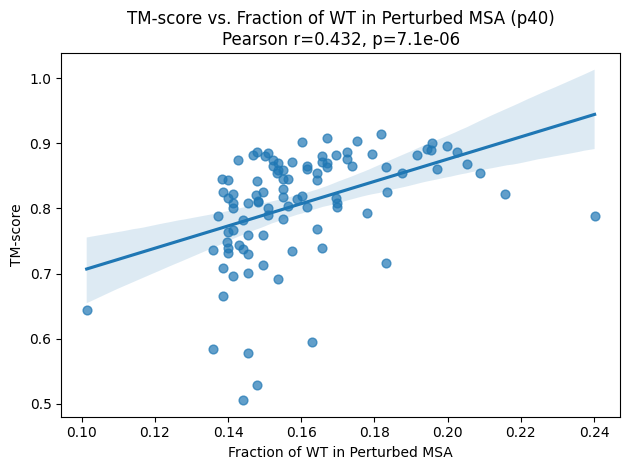

Pearson correlation (jaccard vs. tm_score): r=0.432, p-value=7.1e-06


In [31]:
# use sns to plot distribution of corr_mean vs tm_score
from scipy.stats import pearsonr

def plot_correlation_with_reg_line(df, x_col, y_col, title=None, xlabel=None, ylabel=None):
    """
    Plots a scatterplot with regression line for any two columns of a DataFrame,
    shows Pearson correlation coefficient and p-value.
    """
    # Scatter & reg line
    ax = sns.regplot(x=x_col, y=y_col, data=df, scatter_kws={'s': 40, 'alpha': 0.7})
    # Calculate Pearson r and p
    x = df[x_col]
    y = df[y_col]
    r, p = pearsonr(x, y)
    # Title and labels
    if not title:
        title = f"{y_col} vs. {x_col}"
    if not xlabel:
        xlabel = x_col
    if not ylabel:
        ylabel = y_col
    ax.set_title(f"{title}\nPearson r={r:.3f}, p={p:.2g}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()
    print(f"Pearson correlation ({x_col} vs. {y_col}): r={r:.3f}, p-value={p:.2g}")

# Example usage: scatterplot with regression line and stats
plot_correlation_with_reg_line(
    p40_aggregate, 
    x_col="jaccard", 
    y_col="tm_score",
    title="TM-score vs. Fraction of WT in Perturbed MSA (p40)",
    xlabel="Fraction of WT in Perturbed MSA",
    ylabel="TM-score"
)
